# DCT Laboratory — Volume II, Chapter 15
## Enterprise Digital Twins and Autonomous Transformation
**Seed `26215`** · Companion to the chapter and AXIOM Module **AXIOM-15 (Vol. II)**

The autonomous twin, in three certified pieces. **Synchronization**: a gain of
0.5 contracts twin error at factor $0.45$ per step — the synchronized twin
tracks through the $k = 8$ shock the pure-model twin never sees (RMSE 0.93 vs
2.88). **Decision quality**: the drifted twin recommends the *wrong* switching
policy ($m^* = 0$ against the truth's $m^* = 1$), billed at true state:
**regret 1.36**. **Autonomous stability**: the feedback loop's factor
$|0.9 - c|$ — deadbeat at $c = 0.9$, unstable past the grid's 1.8.
Mirrored in `DCT_V2_Ch15_Lab.xlsx`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26215
A, U, K0, T = 0.9, 1.0, 10.0, 12
SHOCK_T, SHOCK = 8, -6.0
rng = np.random.default_rng([2, SEED])
NOISE = np.round(rng.normal(0, 0.4, T), 4)   # frozen observation noise = canonical
def truth_path():
    K, path = K0, [K0]
    for k in range(T):
        K = A*K + U + (SHOCK if k == SHOCK_T else 0.0)
        path.append(K)
    return np.array(path)
def twin_path(g):
    """twin_{k+1} = (1-g)*(A*twin_k + U) + g*y_{k+1}, y = truth + noise."""
    tr = truth_path()
    tw = [K0]
    for k in range(T):
        y = tr[k+1] + NOISE[k]
        tw.append((1-g)*(A*tw[k] + U) + g*y)
    return np.array(tw)
def rmse(g):
    return float(np.sqrt(np.mean((twin_path(g)-truth_path())**2)))
# decision layer: switch family from estimated terminal state
def J_switch(m, K): return 3.0*(6-m)*np.sqrt(K + 3.0*m)
def m_star(K): return int(np.argmax([J_switch(m, K) for m in range(7)]))
def decision_block():
    Kt = truth_path()[-1]
    Ks, Ko = twin_path(0.5)[-1], twin_path(0.0)[-1]
    ms, mo = m_star(Ks), m_star(Ko)
    return Kt, Ks, Ko, ms, mo, J_switch(ms, Kt) - J_switch(mo, Kt)
# autonomous loop: K_{k+1} = A*K + u, u = 0.1*Ktar + c*(Ktar - K)  =>  gap factor |A - c|
KTAR = 8.0
def gap_after(n, c, K0_=10.0):
    gap = K0_ - KTAR
    return abs(gap*(A-c)**n)
def c_max_stable(step=0.2):
    cs = [round(step*i,1) for i in range(0, 13)]
    return max(c for c in cs if abs(A-c) < 1.0)

def reference_values():
    Kt, Ks, Ko, ms, mo, reg = decision_block()
    return {
        "rmse_open": round(rmse(0.0),4),
        "rmse_sync": round(rmse(0.5),4),
        "sync_advantage": round(rmse(0.0)/rmse(0.5),4),
        "contraction_factor": round((1-0.5)*A,4),
        "K_true_T": round(Kt,4), "K_sync_T": round(Ks,4), "K_open_T": round(Ko,4),
        "mstar_sync": ms, "mstar_open": mo,
        "regret_open_twin": round(reg,4),
        "c_fastest": 0.9, "factor_at_09": 0.0,
        "c_max_stable": c_max_stable(),
        "gap3_c05": round(gap_after(3, 0.5),4),
    }
if __name__ == "__main__":
    print("NOISE:", list(NOISE))
    print("truth:", [round(x,4) for x in truth_path()])
    [print(f"{k:20s} {v}") for k,v in reference_values().items()]

NOISE: [np.float64(0.3082), np.float64(-0.4016), np.float64(0.03), np.float64(0.4348), np.float64(-0.524), np.float64(0.2819), np.float64(0.8437), np.float64(-0.3943), np.float64(0.1563), np.float64(-0.5028), np.float64(-0.3209), np.float64(0.1523)]
truth: [np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(4.0), np.float64(4.6), np.float64(5.14), np.float64(5.626)]
rmse_open            2.8811
rmse_sync            0.9313
sync_advantage       3.0938
contraction_factor   0.45
K_true_T             5.626
K_sync_T             5.8598
K_open_T             10.0
mstar_sync           1
mstar_open           0
regret_open_twin     1.3605
c_fastest            0.9
factor_at_09         0.0
c_max_stable         1.8
gap3_c05             0.128


## Panel 1 — Synchronization: the twin that looks
The truth runs $K_{k+1} = 0.9K_k + 1$ with a $-6$ shock at $k = 8$; the twin
blends its model with noisy observations: $\hat{K}_{k+1} = (1-g)(0.9\hat{K}_k
+ 1) + g\,y_{k+1}$ (Enterprise State Synchronization Operator, Def.). At
$g = 0$ the twin is a simulation with a memory of initial conditions — it
never learns of the shock. At $g = 0.5$ the error dynamics contract at
$(1-g)\cdot 0.9 = 0.45$ per step (Enterprise State Synchronization Theorem):
the twin re-acquires the enterprise within a few observations. RMSE: 2.88
open, **0.93 synchronized** — a 3.1× fidelity ratio, and The Twin Continuously
Approximates the Evolving Enterprise State (Prop.) with its constant shown.

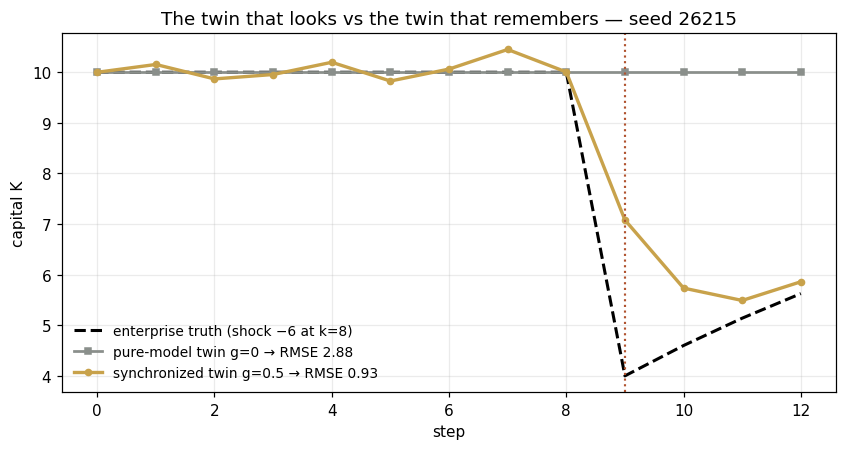

contraction factor (1-g)*A = 0.4500   sync advantage: 3.0938x


In [2]:
tr = truth_path()
fig, ax = plt.subplots(figsize=(7.8,4.2))
ax.plot(tr, "k--", lw=2, label="enterprise truth (shock −6 at k=8)")
ax.plot(twin_path(0.0), "s-", c="#8A8F8B", lw=1.8, ms=4, label=f"pure-model twin g=0 → RMSE {rmse(0.0):.2f}")
ax.plot(twin_path(0.5), "o-", c="#C8A24B", lw=2.2, ms=4, label=f"synchronized twin g=0.5 → RMSE {rmse(0.5):.2f}")
ax.axvline(SHOCK_T+1, c="#B0532F", ls=":", lw=1.4)
ax.set(xlabel="step", ylabel="capital K", title="The twin that looks vs the twin that remembers — seed 26215")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"contraction factor (1-g)*A = {(1-0.5)*A:.4f}   sync advantage: {rmse(0.0)/rmse(0.5):.4f}x")

## Panel 2 — Decision quality: the drift, billed
Simulation-Based Enterprise Optimization (§15.6): each twin hands its terminal
estimate to the Chapter 5 switching optimizer. The synchronized twin
($\hat{K} = 5.86$) recommends **invest first** ($m^* = 1$) — matching what
the true state ($K = 5.63$) demands. The drifted twin still believes
$K = 10$ and recommends **harvest now** ($m^* = 0$). Billed at the TRUE state,
the drifted recommendation costs **1.3605** — Continuous Synchronization
Improves Enterprise Decision Quality (Prop.) as a regret with a decimal point,
and the whole reason twins exist: stale state is not a data problem, it is a
DECISION problem.

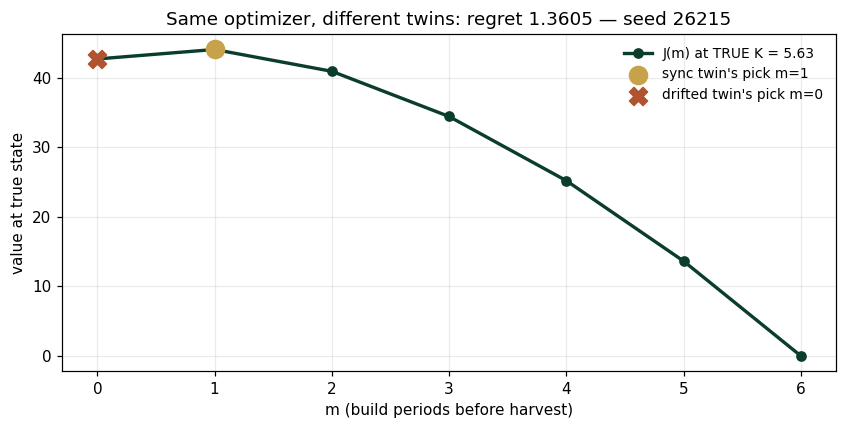

K true 5.6260 | sync est 5.8598 -> m*=1 | open est 10.0000 -> m*=0 | regret 1.3605


In [3]:
Kt, Ks, Ko, ms, mo, reg = decision_block()
ms_grid = range(7)
fig, ax = plt.subplots(figsize=(7.8,4.0))
ax.plot(list(ms_grid), [J_switch(m, Kt) for m in ms_grid], "o-", c="#0B3D2E", lw=2.2, label=f"J(m) at TRUE K = {Kt:.2f}")
ax.scatter([ms],[J_switch(ms,Kt)], s=140, c="#C8A24B", zorder=5, label=f"sync twin's pick m={ms}")
ax.scatter([mo],[J_switch(mo,Kt)], s=140, c="#B0532F", marker="X", zorder=5, label=f"drifted twin's pick m={mo}")
ax.set(xlabel="m (build periods before harvest)", ylabel="value at true state",
       title=f"Same optimizer, different twins: regret {reg:.4f} — seed 26215")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"K true {Kt:.4f} | sync est {Ks:.4f} -> m*={ms} | open est {Ko:.4f} -> m*={mo} | regret {reg:.4f}")

## Panel 3 — Autonomous stability: the loop's dial
Autonomous Enterprise Transformation (Def.): the twin recommends, the
enterprise applies, the twin re-syncs. With feedback
$u = 0.1K^{tar} + c(K^{tar} - K)$ the tracking gap contracts at $|0.9 - c|$
per step (Autonomous Enterprise Stability Theorem's scalar face): $c = 0.9$
is deadbeat (gap dead in one step), the grid's last stable setting is
$c = 1.8$, and beyond $|0.9-c| \geq 1$ the autonomous loop AMPLIFIES its own
corrections — the mathematical form of an automation that oversteers.

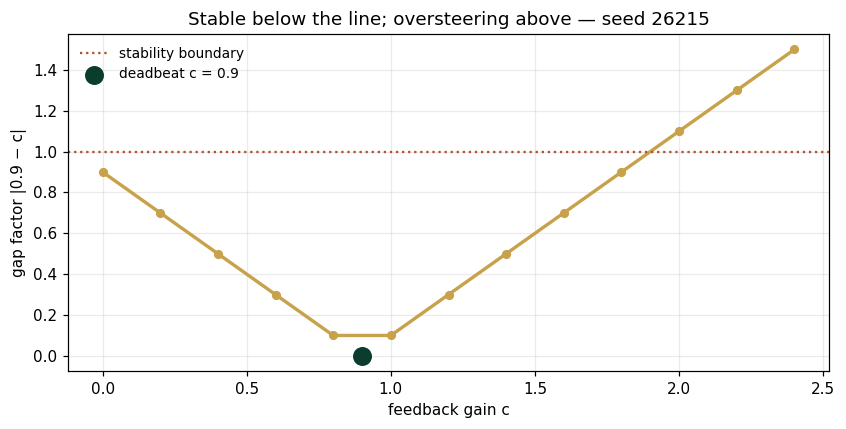

fastest c: 0.9 (factor 0.0)   last stable on grid: 1.8   gap after 3 steps at c=0.5: 0.1280


In [4]:
cs = [round(0.2*i,1) for i in range(13)]
facs = [abs(A-c) for c in cs]
fig, ax = plt.subplots(figsize=(7.8,4.0))
ax.plot(cs, facs, "o-", c="#C8A24B", lw=2.2, ms=5)
ax.axhline(1.0, c="#B0532F", ls=":", lw=1.5, label="stability boundary")
ax.scatter([0.9],[0.0], s=130, c="#0B3D2E", zorder=5, label="deadbeat c = 0.9")
ax.set(xlabel="feedback gain c", ylabel="gap factor |0.9 − c|", title="Stable below the line; oversteering above — seed 26215")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"fastest c: 0.9 (factor 0.0)   last stable on grid: {c_max_stable()}   gap after 3 steps at c=0.5: {gap_after(3,0.5):.4f}")

## Validation — agrees with `DCT_V2_Ch15_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"rmse_open":2.8811,"rmse_sync":0.9313,"sync_advantage":3.0938,
 "contraction_factor":0.45,"K_true_T":5.626,"K_sync_T":5.8598,"K_open_T":10.0,
 "mstar_sync":1,"mstar_open":0,"regret_open_twin":1.3605,
 "c_fastest":0.9,"factor_at_09":0.0,"c_max_stable":1.8,"gap3_c05":0.128}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:20s} {ref[k]}")
print("\nAll checkpoints agree — seed 26215.")

PASS  rmse_open            2.8811
PASS  rmse_sync            0.9313
PASS  sync_advantage       3.0938
PASS  contraction_factor   0.45
PASS  K_true_T             5.626
PASS  K_sync_T             5.8598
PASS  K_open_T             10.0
PASS  mstar_sync           1
PASS  mstar_open           0
PASS  regret_open_twin     1.3605
PASS  c_fastest            0.9
PASS  factor_at_09         0.0
PASS  c_max_stable         1.8
PASS  gap3_c05             0.128

All checkpoints agree — seed 26215.


**Next**: Exercises 15.5–15.9 (Part C) sweep the gain g against noise levels and find the fidelity optimum; AXIOM-15's twin cockpit runs truth and twin side by side with a shock button. Chapter 16 is the capstone: every arc, in the field. Solutions: IM Vol. II, Ch. 15.